In [28]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

# print("Path to dataset files:", path)

**Path to dataset files:** C:\Users\DELL\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1
**Link: ** https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset

In [29]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import shutil
import random


In [30]:
# 1. Definisikan Path
dataset_path = "PetImages"
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')


In [31]:


# 2. Fungsi untuk membagi dataset (80% Train, 20% Test)
def split_data(base_path, categories, split_size=0.8):
    for category in categories:
        category_path = os.path.join(base_path, category)
        
        # Cek apakah folder kategori (Cat/Dog) ada
        if not os.path.exists(category_path) or category in ['train', 'test']:
            continue
            
        # Ambil daftar file dan acak
        files = [f for f in os.listdir(category_path) if os.path.getsize(os.path.join(category_path, f)) > 0]
        random.shuffle(files)
        
        # Tentukan titik pemisah
        train_count = int(len(files) * split_size)
        
        # Buat folder train dan test untuk kategori tersebut
        os.makedirs(os.path.join(train_dir, category), exist_ok=True)
        os.makedirs(os.path.join(test_dir, category), exist_ok=True)
        
        # Pindahkan file ke folder train
        for f in files[:train_count]:
            shutil.move(os.path.join(category_path, f), os.path.join(train_dir, category, f))
            
        # Pindahkan file sisanya ke folder test
        for f in files[train_count:]:
            shutil.move(os.path.join(category_path, f), os.path.join(test_dir, category, f))
        
        # Hapus folder asli yang sudah kosong
        os.rmdir(category_path)

# Eksekusi pembagian folder jika belum terbagi
if os.path.exists(os.path.join(dataset_path, "Cat")):
    split_data(dataset_path, ["Cat", "Dog"])
    print("Dataset berhasil dibagi menjadi train dan test.")

# 3. Data Augmentation dan Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    # rotation_range=40, 
    # # width_shift_range=0.2, 
    # # height_shift_range=0.2, 
    # # shear_range=0.2, 
    # # zoom_range=0.2, 
    # horizontal_flip=True, 
    # fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# 4. Generator
train_generator = train_datagen.flow_from_directory(
    train_dir, 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, 
    target_size=(224, 224), 
    batch_size=64, 
    class_mode='binary'
)

Found 19998 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Pastikan TensorFlow mengabaikan gambar yang rusak saat training
from PIL import Image
Image.MAX_IMAGE_PIXELS = None 

# 1. Membangun Model
model = Sequential([
    # Hanya menggunakan 2 layer Konvolusi untuk meringankan beban komputasi
    Conv2D(16, (6, 6), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(32, (6, 6), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    # Mengurangi jumlah neuron dari 512 ke 128
    Dense(64, activation='relu'),
    Dropout(0.2), 
    Dense(1, activation='sigmoid')
])

# 2. Compile
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Tips: Tambahkan penanganan error jika ada gambar corrupt di tengah training
try:
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=test_generator,
        verbose=1
    )
except Exception as e:
    print(f"\nTerjadi error saat training: {e}")


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 394s 624ms/step - accuracy: 0.5966 - loss: 0.6903 - val_accuracy: 0.6356 - val_loss: 0.6381
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 349s 559ms/step - accuracy: 0.6943 - loss: 0.5883 - val_accuracy: 0.7190 - val_loss: 0.5600
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 343s 549ms/step - accuracy: 0.7567 - loss: 0.5001 - val_accuracy: 0.7362 - val_loss: 0.5392
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 227s 363ms/step - accuracy: 0.8214 - loss: 0.3915 - val_accuracy: 0.7456 - val_loss: 0.5394
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 358ms/step - accuracy: 0.8798 - loss: 0.2724 - val_accuracy: 0.7468 - val_loss: 0.6380
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 362ms/step - accuracy: 0.9230 - loss: 0.1831 - val_accuracy: 0.7470 - val_loss: 0.7817
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 225s 360ms/step - accuracy: 0.9442 - loss: 0.1299 - val_accuracy: 0.7360 - val_loss: 0.9628
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 224s 359ms/step - accuracy: 0.9558 -

In [34]:
model.save('image_clasification.h5')

use model
```
from tensorflow.keras.models import load_model

# Memuat model yang sudah disimpan
model = load_model('nama_model_kamu.h5')
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # 1. Load gambar dan ubah ukurannya menjadi 224x224
    img = image.load_img(img_path, target_size=(224, 224))
    
    # 2. Ubah gambar menjadi array angka
    img_array = image.img_to_array(img)
    
    # 3. Tambahkan dimensi batch (karena model expect input [batch_size, height, width, channels])
    img_array = np.expand_dims(img_array, axis=0)
    
    # 4. Normalisasi (penting! harus sama dengan saat training, biasanya dibagi 255)
    img_array = img_array / 255.0
    
    # 5. Prediksi
    prediction = model.predict(img_array)
    
    # Karena pakai aktivasi 'sigmoid', hasilnya berupa angka antara 0 sampai 1
    if prediction[0] > 0.5:
        print(f"Hasil: Kelas B (Skor: {prediction[0][0]:.2f})")
    else:
        print(f"Hasil: Kelas A (Skor: {prediction[0][0]:.2f})")

# Contoh penggunaan:
predict_image('path/ke/gambar_baru.jpg')
```

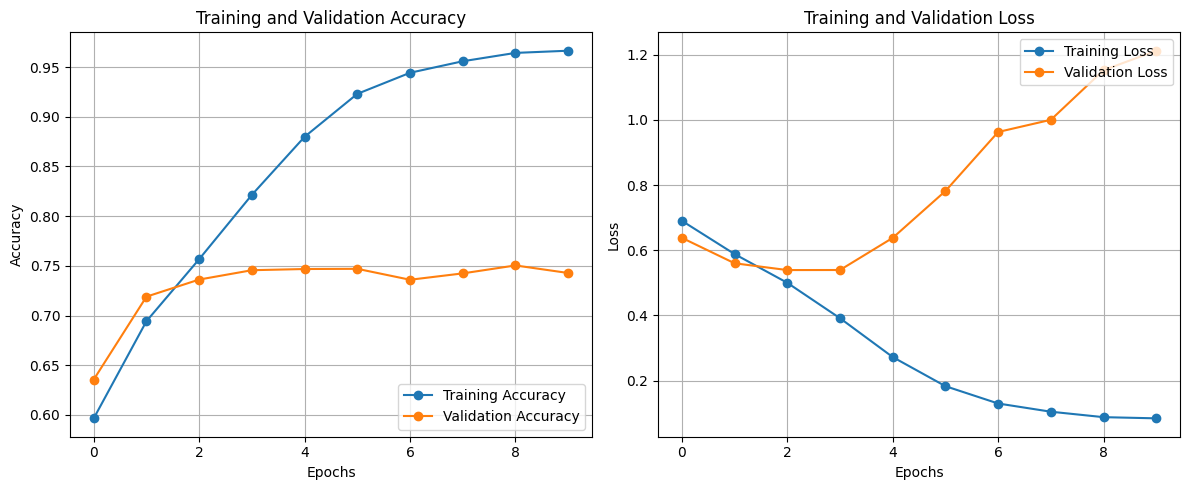

In [33]:
import matplotlib.pyplot as plt

# Ambil data dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Gunakan panjang data asli dari history (biar tidak error jika epochs berubah)
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5)) # Ukuran lebih proporsional untuk dua plot ke samping

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True) # Tambah grid agar lebih mudah dibaca

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout() # Mengatur jarak antar subplot agar tidak tumpang tindih
plt.show()
